In [ ]:
!pip uninstall -y ultralytics
!pip install ultralytics

In [25]:
import os
import glob
import yaml
import random
import cv2
import pandas as pd
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from PIL import Image

In [3]:
import kagglehub

#Download Versi Dataset Terbaru
path = kagglehub.dataset_download("quinnmlee/waste-3class-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/quinnmlee/waste-3class-classification


In [4]:
print(os.path.exists(f"{path}/dataset_split/data.yaml"))
print(len(os.listdir(f"{path}/dataset_split/train/images")))
print(len(os.listdir(f"{path}/dataset_split/train/labels")))

True
6274
6221


In [5]:
dataset_path = None

for p in Path("/kaggle/input").rglob("dataset_split"):
    if (p / "train/images").exists():
        if (p / "valid/images").exists() or (p / "val/images").exists():
            dataset_path = p
            break

if dataset_path is None:
    raise FileNotFoundError("dataset_split tidak ditemukan atau struktur folder tidak sesuai.")

print("Dataset path:", dataset_path)

Dataset path: /kaggle/input/datasets/quinnmlee/waste-3class-classification/dataset_split


In [6]:
data_yaml = {
    "path": str(dataset_path),
    "train": "train/images",
    "val": "valid/images",
    "nc": 3,
    "names": ["Organik", "Anorganik", "B3"]
}

if (dataset_path / "test/images").exists():
    data_yaml["test"] = "test/images"

fixed_yaml_path = "/kaggle/working/data_fixed.yaml"

with open(fixed_yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("\nIsi data_fixed.yaml:")
with open(fixed_yaml_path) as f:
    print(f.read())


Isi data_fixed.yaml:
path: /kaggle/input/datasets/quinnmlee/waste-3class-classification/dataset_split
train: train/images
val: valid/images
nc: 3
names:
- Organik
- Anorganik
- B3
test: test/images



In [7]:
#Train Model Yolov8 Nano
model = YOLO("yolov8n.pt")

model.train(
    data=fixed_yaml_path, # Use the path to the updated data.yaml
    epochs=100,
    imgsz=640
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c53be1f4f50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [9]:
 # dari kagglehub

with open(f"{path}/dataset_split/data.yaml", 'r') as f:
    data = yaml.safe_load(f)

train_path = data['train']
val_path = data['val']
class_names = data['names']

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['organik', 'anorganik', 'b3']
Number of classes: 3


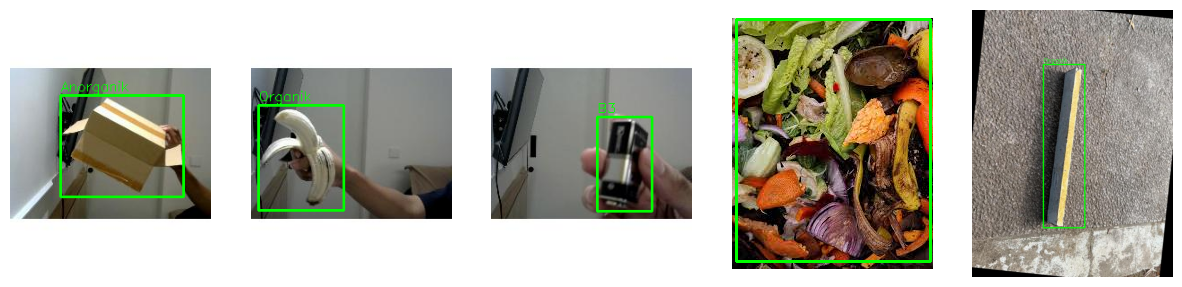

In [43]:
dataset_path = f"{path}/dataset_split"

def show_samples(image_dir, label_dir, n=5):
    images = glob.glob(f"{image_dir}/*.jpg")
    samples = random.sample(images, n)

    plt.figure(figsize=(15, 8))

    for i, img_path in enumerate(samples):
        img = cv2.imread(img_path)
        h, w, _ = img.shape

        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    try:
                        cls, x, y, bw, bh = map(float, line.split())
                    except ValueError:
                        continue

                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                    cv2.putText(img, class_names[int(cls)], (x1, y1-5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        plt.subplot(1, n, i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.show()

show_samples(f"{dataset_path}/train/images", f"{dataset_path}/train/labels")

Jumlah file label: 6221
Counter: Counter({1: 3817, 0: 2070, 2: 1756, 3: 1})


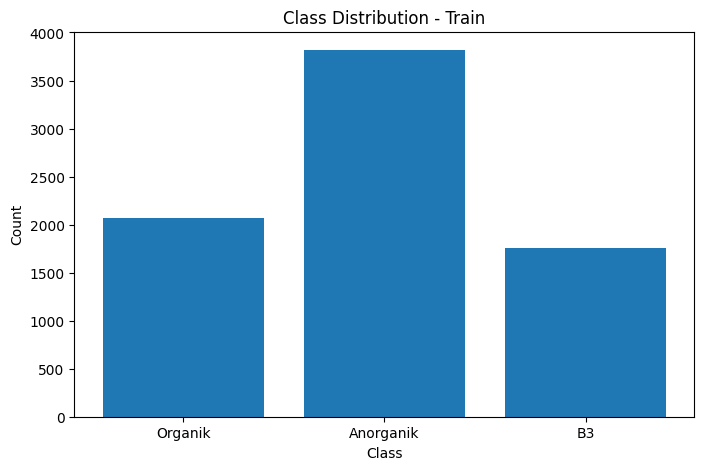

In [39]:
class_names = ["Organik", "Anorganik", "B3"]

label_files = glob.glob(f"{dataset_path}/train/labels/*.txt")

print("Jumlah file label:", len(label_files))

counter = Counter()

for file in label_files:
    with open(file) as f:
        for line in f.readlines():
            if line.strip():
                cls = int(line.split()[0])
                counter[cls] += 1

print("Counter:", counter)

# Ambil class id yang valid: 0, 1, 2
valid_class_ids = sorted([i for i in counter.keys() if 0 <= i < len(class_names)])

classes = [class_names[i] for i in valid_class_ids]
counts = [counter[i] for i in valid_class_ids]

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.title("Class Distribution - Train")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

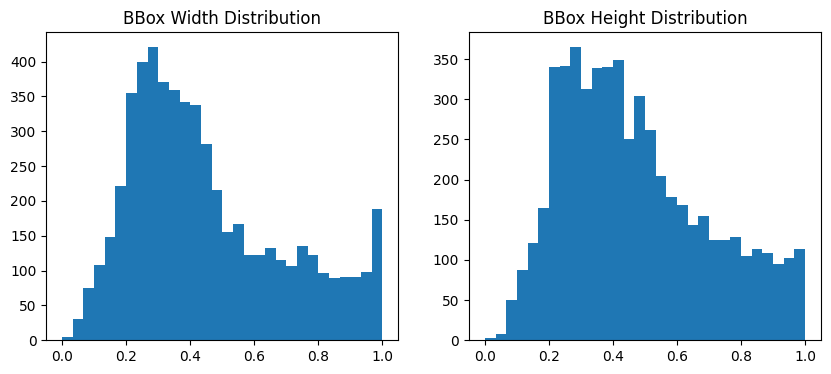

In [17]:
widths = []
heights = []

for file in label_files:
    with open(file) as f:
        for line in f.readlines():
            try:
                _, _, _, w, h = map(float, line.split())
            except ValueError:
                continue
            widths.append(w)
            heights.append(h)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("BBox Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("BBox Height Distribution")

plt.show()

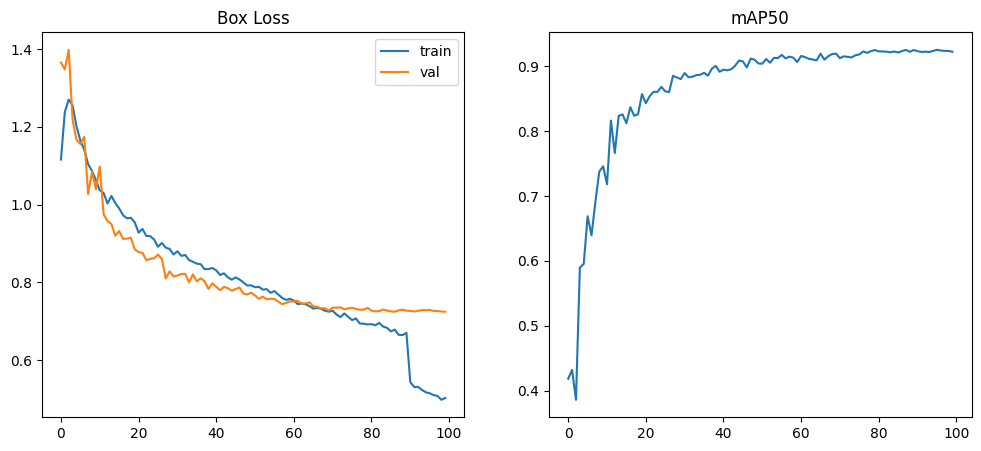

In [22]:
results = pd.read_csv("runs/detect/train/results.csv")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(results['train/box_loss'], label='train')
plt.plot(results['val/box_loss'], label='val')
plt.title("Box Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(results['metrics/mAP50(B)'])
plt.title("mAP50")

plt.show()

(np.float64(-0.5), np.float64(2249.5), np.float64(1499.5), np.float64(-0.5))

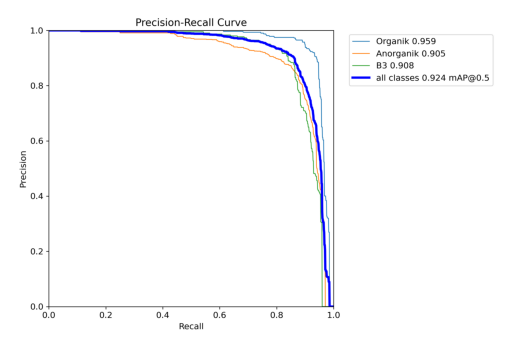

In [27]:
img = Image.open("runs/detect/train/BoxPR_curve.png")
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

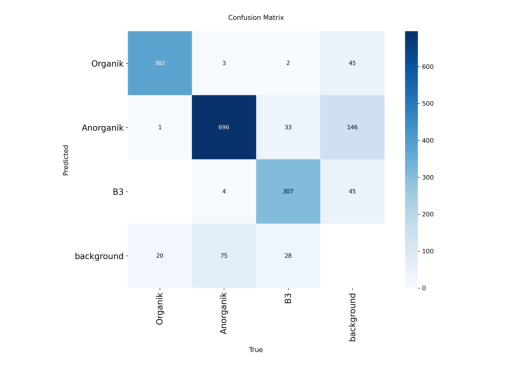

In [28]:
img = Image.open("runs/detect/train/confusion_matrix.png")
plt.imshow(img)
plt.axis("off")

### **Predicting**

In [30]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model(f"{dataset_path}/valid/images", save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1214 /kaggle/input/datasets/quinnmlee/waste-3class-classification/dataset_split/valid/images/1593680238529.jpeg: 448x640 3 Anorganiks, 1 B3, 43.4ms
image 2/1214 /kaggle/input/datasets/quinnmlee/waste-3class-classification/dataset_split/valid/images/1593680542160.jpeg: 448x640 1 Anorganik, 1 B3, 6.1ms
image 3/1214 /kaggle/input/datasets/quinnmlee/waste-3class-classification/dataset_split/valid/images/1593680542172.jpeg: 448x640 2 Anorganiks, 3 B3s

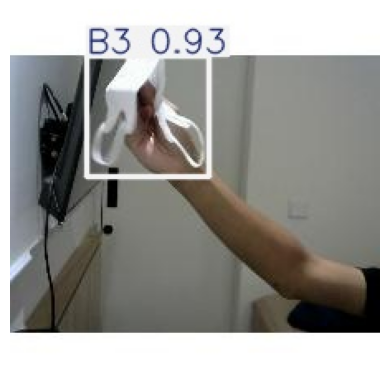

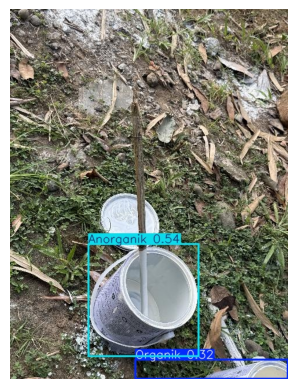

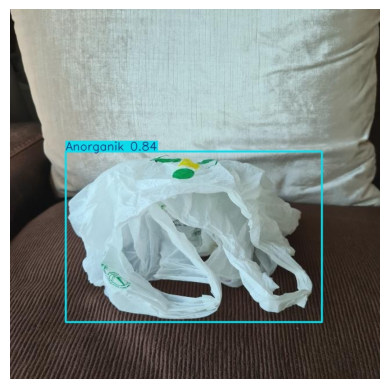

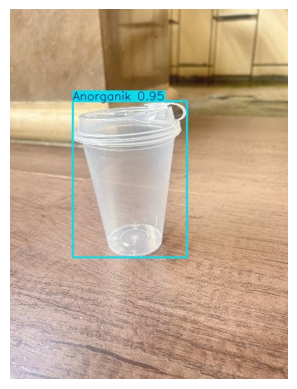

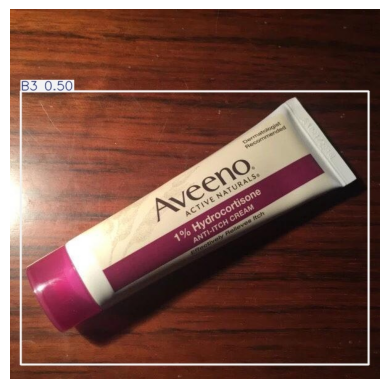

In [31]:
preds = glob.glob("runs/detect/predict/*.jpg")

for i in range(5):
    img = cv2.imread(preds[i])
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()